# Detection Analysis

Analyzes policy vector detection performance.

**Vector**: Positional windowing with mean-difference (on-policy - off-policy)

**Analyses:**
- Detection performance metrics
- Distribution visualizations  
- Projection score analysis

## 1. Setup

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Config
LAYER = 35
MODEL_NAME = 'Qwen/Qwen3-4B'

DATA_ROOT = Path('..') / 'data'
ARTIFACT_ROOT = Path('..') / 'artifacts'
RESULTS_ROOT = Path('..') / 'results'

RESULTS_ROOT.mkdir(exist_ok=True)

## 2. Load Pre-Extracted Vectors

In [2]:
# Load vectors
with open(ARTIFACT_ROOT / 'vector_first3.json') as f:
    vector_data = json.load(f)

vector = vector_data['vectors'][str(LAYER)]
print(f"Using Layer {LAYER}")
total_samples = vector_data.get('total_samples')
if total_samples is not None:
    print(f"Training samples: {total_samples}")
else:
    print("Training samples: <unknown>")

# Load dataset
with open(DATA_ROOT / 'off_policy.json') as f:
    dataset = json.load(f)

print(f"\nDataset: {len(dataset)} prompts")
print(f"On-policy: {sum(len(ex['on_policy']) for ex in dataset)} rollouts")
print(f"Off-policy: {sum(len(ex['off_policy']) for ex in dataset)} variants (1:1 mapping)")

Using Layer 35
Training samples: 600

Dataset: 40 prompts
On-policy: 200 rollouts
Off-policy: 600 variants (1:1 mapping)


## 3. Load Model

In [3]:
print(f"Loading {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map='auto', torch_dtype='auto')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print("Model loaded")

Loading Qwen/Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Model loaded


## 4. Compute Projections

In [4]:
def compute_projection(prompt_template: str, completion: str, vector: list, layer: int) -> float:
    """Compute projection onto unit vector."""
    unit_vec = torch.tensor(vector, dtype=torch.float32).to(model.device)
    unit_vec = unit_vec / (torch.linalg.norm(unit_vec) + 1e-8)
    
    full = prompt_template + completion
    inputs = tokenizer(full, return_tensors='pt').to(model.device)
    prompt_len = len(tokenizer(prompt_template)['input_ids'])
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True, use_cache=False)
    
    hidden = outputs.hidden_states[layer + 1][0][prompt_len:]
    pooled = hidden.mean(dim=0).to(torch.float32)
    return float((pooled @ unit_vec).item())

# Compute projections
print(f"\nComputing projections for layer {LAYER}...")

results = []
for ex in tqdm(dataset, desc='Computing projections'):
    prompt = ex['prompt_with_template']
    
    # On-policy
    for completion in ex['on_policy']:
        proj = compute_projection(prompt, completion, vector, LAYER)
        results.append({
            'type': 'on_policy',
            'projection': proj
        })
    
    # Off-policy
    for variant in ex['off_policy']:
        proj = compute_projection(prompt, variant['text'], vector, LAYER)
        results.append({
            'type': 'off_policy',
            'projection': proj
        })

results_df = pd.DataFrame(results)
print(f"\nCollected {len(results_df)} projections")


Computing projections for layer 35...


Computing projections:   0%|          | 0/40 [00:00<?, ?it/s]


Collected 800 projections


## 5. Compute Metrics

In [5]:
def cohens_d(a, b):
    diff = np.mean(a) - np.mean(b)
    pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return diff / (pooled + 1e-8)

on = results_df[results_df['type'] == 'on_policy']['projection'].values
off = results_df[results_df['type'] == 'off_policy']['projection'].values

threshold = (on.mean() + off.mean()) / 2
on_acc = (on > threshold).mean()
off_acc = (off <= threshold).mean()

u_stat, p_val = mannwhitneyu(on, off, alternative='two-sided')
auc = u_stat / (len(on) * len(off))

metrics = {
    'layer': LAYER,
    'mean_on': on.mean(),
    'std_on': on.std(ddof=1),
    'mean_off': off.mean(),
    'std_off': off.std(ddof=1),
    'cohens_d': cohens_d(on, off),
    'auc': auc,
    'mann_whitney_p': p_val,
    'on_acc': on_acc,
    'off_acc': off_acc,
    'balanced_acc': (on_acc + off_acc) / 2,
    'num_on': len(on),
    'num_off': len(off)
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

# Save
metrics_df.to_csv(RESULTS_ROOT / f'detection_metrics_layer{LAYER}.csv', index=False)
print(f"\nSaved metrics to {RESULTS_ROOT / f'detection_metrics_layer{LAYER}.csv'}")

,layer,mean_on,std_on,mean_off,std_off,cohens_d,auc,mann_whitney_p,on_acc,off_acc,balanced_acc,num_on,num_off
0,35,-0.285759,5.295844,-31.694523,4.530195,6.373646,1.0,9.594172e-100,1.0,1.0,1.0,200,600



Saved metrics to ../results/detection_metrics_layer35.csv


## 6. Visualizations

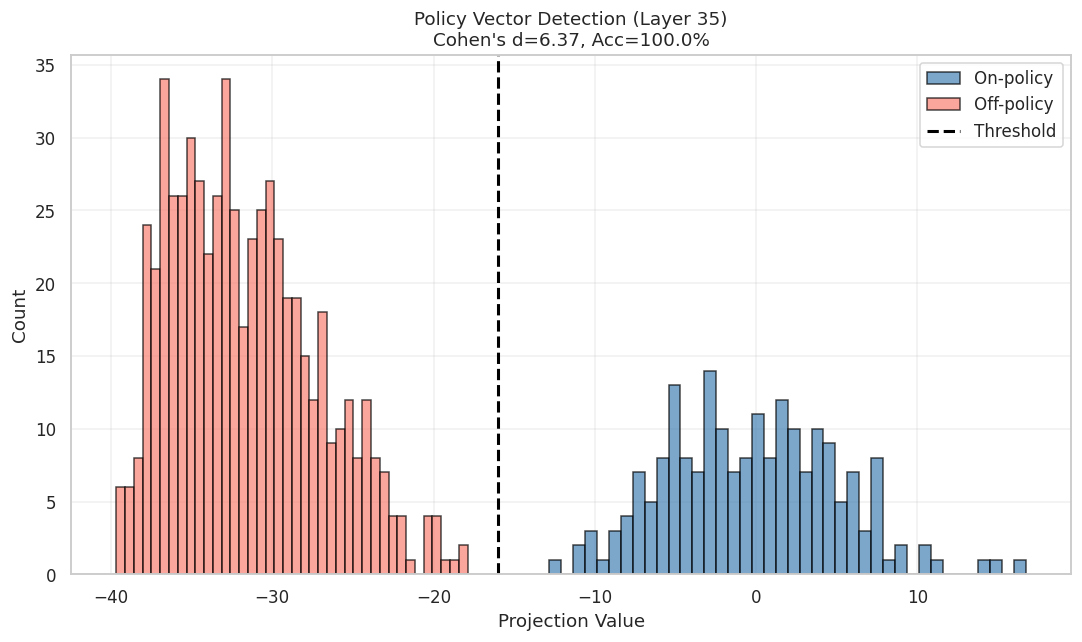

Saved visualization to ../results/projection_distribution_layer35.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

on_proj = results_df[results_df['type'] == 'on_policy']['projection']
off_proj = results_df[results_df['type'] == 'off_policy']['projection']

ax.hist(on_proj, bins=40, alpha=0.7, label='On-policy', color='steelblue', edgecolor='black')
ax.hist(off_proj, bins=40, alpha=0.7, label='Off-policy', color='salmon', edgecolor='black')

ax.axvline(threshold, color='black', linestyle='--', linewidth=2, label='Threshold')

ax.set_xlabel('Projection Value')
ax.set_ylabel('Count')
ax.set_title(f"Policy Vector Detection (Layer {LAYER})\nCohen's d={metrics['cohens_d']:.2f}, Acc={metrics['balanced_acc']*100:.1f}%")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_ROOT / f'projection_distribution_layer{LAYER}.png', dpi=140)
plt.show()

print(f"Saved visualization to {RESULTS_ROOT / f'projection_distribution_layer{LAYER}.png'}")

## 7. Summary

In [7]:
print("=" * 60)
print("DETECTION PERFORMANCE SUMMARY")
print("=" * 60)
print(f"\nPolicy Vector (Layer {metrics['layer']}):")
print(f"  Cohen's d: {metrics['cohens_d']:.3f}")
print(f"  ROC AUC: {metrics['auc']:.3f}")
print(f"  Balanced Accuracy: {metrics['balanced_acc']*100:.1f}%")
print(f"  On-policy:  {metrics['mean_on']:7.2f} ± {metrics['std_on']:.2f}")
print(f"  Off-policy: {metrics['mean_off']:7.2f} ± {metrics['std_off']:.2f}")

DETECTION PERFORMANCE SUMMARY

Policy Vector (Layer 35):
  Cohen's d: 6.374
  ROC AUC: 1.000
  Balanced Accuracy: 100.0%
  On-policy:    -0.29 ± 5.30
  Off-policy:  -31.69 ± 4.53
